# Interactive Latent-to-Shape Visualization (MLP VAE)

This notebook loads the trained VAE + DeepSDF models for **real labels** and **pseudo labels** and lets you interactively adjust each latent dimension to see the output shape.

- Initial slider values are set to the mean of the saved 8D latents.
- Slider ranges are derived from the min/max of the saved latents.
- Use the **Render** button (or enable Auto Update) to regenerate the mesh.


In [83]:
import os
import json
import numpy as np
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from ipywidgets import (
    FloatSlider, IntSlider, Dropdown, Button, VBox, HBox, Label, Output, Checkbox
)
from IPython.display import display, clear_output, HTML
from skimage import measure
import trimesh

from networks import deep_sdf_decoder
from networks import residual_mlp_vae
import deep_sdf.workspace as ws
import deep_sdf.utils as sdf_utils
import train_MLP_VAE_deep_sdf as train_vae

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    import anywidget as _anywidget  # noqa: F401
    _HAS_ANYWIDGET = True
except Exception:
    _HAS_ANYWIDGET = False
    print("anywidget not found; view persistence disabled (install anywidget to keep camera view).")

try:
    import nbformat as _nbformat
    _HAS_NBFORMAT = True
except Exception:
    _HAS_NBFORMAT = False
    print("nbformat not found; using HTML renderer for Plotly.")

def display_plotly(fig):
    if _HAS_NBFORMAT:
        display(fig)
    else:
        display(HTML(fig.to_html(include_plotlyjs="cdn")))


Using device: cuda
anywidget not found; view persistence disabled (install anywidget to keep camera view).
nbformat not found; using HTML renderer for Plotly.


In [84]:
# Update these paths if your experiment folders are elsewhere.
EXPERIMENTS = {
    "real_label": "examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_all_true_label",
    "pseudo_label": "examples/ADNI_1_L_No_MCI/MLP_VAE_SDF_disentangle_pseudo_label_only",
}

MODEL_FILENAME = "latest.pth"
LATENTS_FILENAME = "latest.pth"

In [85]:
def load_specs(exp_dir):
    specs_path = os.path.join(exp_dir, "specs.json")
    with open(specs_path, "r") as f:
        return json.load(f)


def build_models(specs):
    code_len = specs["CodeLength"]
    sdf_decoder = deep_sdf_decoder.Decoder(code_len, **specs["NetworkSpecs"])
    vae = residual_mlp_vae.ResidualMLPVAE(
        input_dim=specs.get("VAEInputDim", code_len),
        latent_dim=specs.get("VAELatentDim", 8),
        encoder_hidden_dims=specs.get("VAEEncoderHiddenDims", [256, 128]),
        decoder_hidden_dims=specs.get("VAEDecoderHiddenDims", [128, 256, 256]),
        num_blocks=specs.get("VAEBlocks", 1),
        activation=specs.get("VAEActivation", "gelu"),
        dropout=specs.get("VAEDropout", 0.0),
        use_layernorm=specs.get("VAELayerNorm", True),
        use_kl=specs.get("UseKLLoss", True),
    )
    return vae, sdf_decoder


def load_models(exp_dir, device):
    specs = load_specs(exp_dir)
    vae, sdf_decoder = build_models(specs)
    epoch = train_vae.load_model(exp_dir, MODEL_FILENAME, vae, sdf_decoder)
    vae.to(device).eval()
    sdf_decoder.to(device).eval()
    return specs, vae, sdf_decoder, epoch


def load_latents(exp_dir):
    latent_path = os.path.join(exp_dir, "LatentCodes", LATENTS_FILENAME)
    latents = train_vae.load_latent_codes_from_file(latent_path)
    if isinstance(latents, dict):
        keys = sorted(latents.keys())
        latents = torch.stack([latents[k] for k in keys], dim=0)
    if isinstance(latents, torch.Tensor):
        if latents.dim() == 3 and latents.size(1) == 1:
            latents = latents[:, 0, :]
        return latents.float()
    raise ValueError("Unexpected latent format")


def latent_stats(latents):
    minv = latents.min(dim=0).values
    maxv = latents.max(dim=0).values
    meanv = latents.mean(dim=0)
    return minv, maxv, meanv


def create_mesh_from_decoder(decoder, latent_vec, N=64, max_batch=32768, device="cuda", return_sdf=False):
    decoder.eval()
    voxel_origin = [-1.0, -1.0, -1.0]
    voxel_size = 2.0 / (N - 1)

    overall_index = torch.arange(0, N ** 3, 1, dtype=torch.long)
    samples = torch.zeros(N ** 3, 4)
    samples[:, 2] = overall_index % N
    samples[:, 1] = (overall_index.long() / N) % N
    samples[:, 0] = ((overall_index.long() / N) / N) % N

    samples[:, 0] = (samples[:, 0] * voxel_size) + voxel_origin[2]
    samples[:, 1] = (samples[:, 1] * voxel_size) + voxel_origin[1]
    samples[:, 2] = (samples[:, 2] * voxel_size) + voxel_origin[0]

    num_samples = N ** 3
    head = 0
    while head < num_samples:
        end = min(head + max_batch, num_samples)
        sample_subset = samples[head:end, 0:3].to(device)
        with torch.no_grad():
            pred = sdf_utils.decode_sdf(decoder, latent_vec, sample_subset)
            pred = pred.squeeze(1).detach().cpu()
        samples[head:end, 3] = pred
        head = end

    sdf_values = samples[:, 3].reshape(N, N, N).numpy()

    try:
        verts, faces, normals, _ = measure.marching_cubes(
            sdf_values, level=0.0, spacing=[voxel_size] * 3, method="lewiner"
        )
    except ValueError as exc:
        print(f"Marching cubes failed: {exc}")
        if return_sdf:
            return None, None, None, None
        return None

    mesh_points = np.zeros_like(verts)
    mesh_points[:, 0] = voxel_origin[0] + verts[:, 0]
    mesh_points[:, 1] = voxel_origin[1] + verts[:, 1]
    mesh_points[:, 2] = voxel_origin[2] + verts[:, 2]

    mesh = trimesh.Trimesh(vertices=mesh_points, faces=faces, vertex_normals=normals, process=False)
    if return_sdf:
        return mesh, sdf_values, np.array(voxel_origin), voxel_size
    return mesh


def latent_to_mesh(z, vae, sdf_decoder, device, grid_n=64, max_batch=32768, return_sdf=False):
    z_tensor = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        z_hat = vae.decoder(z_tensor)
    return create_mesh_from_decoder(
        sdf_decoder, z_hat, N=grid_n, max_batch=max_batch, device=device, return_sdf=return_sdf
    )


def volume_from_sdf(sdf_values, voxel_size):
    if sdf_values is None or voxel_size is None:
        return None
    inside = sdf_values < 0
    return float(np.sum(inside)) * (voxel_size ** 3)


def intensity_from_diff_grid(mesh, diff_grid, voxel_origin, voxel_size):
    if mesh is None or diff_grid is None or voxel_origin is None or voxel_size is None:
        return None
    v = mesh.vertices
    idx = np.rint((v - voxel_origin) / voxel_size).astype(int)
    max_idx = np.array(diff_grid.shape) - 1
    idx = np.clip(idx, 0, max_idx)
    vals = diff_grid[idx[:, 0], idx[:, 1], idx[:, 2]]
    maxv = float(np.max(vals)) if vals.size else 0.0
    if maxv <= 1e-8:
        return np.zeros_like(vals)
    return vals / maxv


def _prepare_vertices(mesh, upright=False):
    v = mesh.vertices.copy()
    if upright:
        # Rotate +90 deg around X so Z becomes up (swap Y/Z).
        v = np.stack([v[:, 0], v[:, 2], -v[:, 1]], axis=1)
    return v


def build_dual_top_view_figure(base_mesh, change_mesh, title=None, upright=False, intensity=None):
    base_v = _prepare_vertices(base_mesh, upright=upright)
    base_f = base_mesh.faces
    change_v = _prepare_vertices(change_mesh, upright=upright)
    change_f = change_mesh.faces

    fig = make_subplots(
        rows=2, cols=1,
        specs=[[{'type': 'scene'}], [{'type': 'scene'}]],
        vertical_spacing=0.02,
        subplot_titles=('Base Shape', 'Change Map'),
    )

    fig.add_trace(
        go.Mesh3d(
            x=base_v[:, 0], y=base_v[:, 1], z=base_v[:, 2],
            i=base_f[:, 0], j=base_f[:, 1], k=base_f[:, 2],
            color='skyblue', opacity=1.0,
        ),
        row=1, col=1
    )

    if intensity is None:
        intensity = np.zeros(change_v.shape[0], dtype=np.float32)
    fig.add_trace(
        go.Mesh3d(
            x=change_v[:, 0], y=change_v[:, 1], z=change_v[:, 2],
            i=change_f[:, 0], j=change_f[:, 1], k=change_f[:, 2],
            intensity=intensity,
            colorscale=[[0.0, '#FFF9C4'], [1.0, '#FFC107']],
            cmin=0.0, cmax=1.0,
            showscale=False,
            opacity=1.0,
        ),
        row=2, col=1
    )

    fig.update_layout(
        title=title,
        margin=dict(l=0, r=0, b=0, t=30),
        scene_aspectmode='data',
        scene2_aspectmode='data',
        scene_camera=dict(eye=dict(x=0.0, y=0.0, z=2.8)),
        scene2_camera=dict(eye=dict(x=0.0, y=0.0, z=2.8)),
        uirevision='keep',
    )
    fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
    if _HAS_ANYWIDGET:
        return go.FigureWidget(fig)
    return fig


def update_dual_top_view_figure(fig, intensity=None, title=None):
    if intensity is None:
        intensity = np.zeros(fig.data[1].x.shape[0], dtype=np.float32)
    change_trace = fig.data[1]
    with fig.batch_update():
        change_trace.intensity = intensity
        change_trace.colorscale = [[0.0, '#FFF9C4'], [1.0, '#FFC107']]
        change_trace.cmin = 0.0
        change_trace.cmax = 1.0
        change_trace.showscale = False
        if title is not None:
            fig.layout.title = title
    return fig


    base_trace = fig.data[0]
    change_trace = fig.data[1]
    with fig.batch_update():
        base_trace.x = base_v[:, 0]
        base_trace.y = base_v[:, 1]
        base_trace.z = base_v[:, 2]
        base_trace.i = base_f[:, 0]
        base_trace.j = base_f[:, 1]
        base_trace.k = base_f[:, 2]
        base_trace.color = 'skyblue'
        base_trace.opacity = 1.0

        change_trace.x = change_v[:, 0]
        change_trace.y = change_v[:, 1]
        change_trace.z = change_v[:, 2]
        change_trace.i = change_f[:, 0]
        change_trace.j = change_f[:, 1]
        change_trace.k = change_f[:, 2]
        change_trace.intensity = intensity
        change_trace.colorscale = [[0.0, '#FFF9C4'], [1.0, '#FFC107']]
        change_trace.cmin = 0.0
        change_trace.cmax = 1.0
        change_trace.showscale = False
        change_trace.opacity = 1.0
        if title is not None:
            fig.layout.title = title
    return fig


    if change_mesh is None:
        change_mesh = base_mesh
        intensity = None
        change_opacity = 0.0
    else:
        change_opacity = 0.7 if intensity is not None else 0.0

    change_v = _prepare_vertices(change_mesh, upright=upright)
    change_f = change_mesh.faces
    change_trace = fig.data[1]

    with fig.batch_update():
        base_trace.x = base_v[:, 0]
        base_trace.y = base_v[:, 1]
        base_trace.z = base_v[:, 2]
        base_trace.i = base_f[:, 0]
        base_trace.j = base_f[:, 1]
        base_trace.k = base_f[:, 2]
        base_trace.color = 'skyblue'
        base_trace.opacity = 1.0

        change_trace.x = change_v[:, 0]
        change_trace.y = change_v[:, 1]
        change_trace.z = change_v[:, 2]
        change_trace.i = change_f[:, 0]
        change_trace.j = change_f[:, 1]
        change_trace.k = change_f[:, 2]
        change_trace.opacity = change_opacity
        if intensity is None:
            change_trace.intensity = None
            change_trace.colorscale = None
            change_trace.color = '#FFC107'
        else:
            change_trace.color = None
            change_trace.intensity = intensity
            change_trace.colorscale = [[0.0, '#FFF9C4'], [1.0, '#FFC107']]
            change_trace.cmin = 0.0
            change_trace.cmax = 1.0
            change_trace.showscale = False
        if title is not None:
            fig.layout.title = title
    return fig



In [86]:
experiments = {}
for name, exp_dir in EXPERIMENTS.items():
    if not os.path.isdir(exp_dir):
        print(f"Missing experiment dir: {exp_dir}")
        continue
    specs, vae, sdf_decoder, epoch = load_models(exp_dir, device)
    latents = load_latents(exp_dir)
    minv, maxv, meanv = latent_stats(latents)
    experiments[name] = {
        "exp_dir": exp_dir,
        "specs": specs,
        "vae": vae,
        "sdf_decoder": sdf_decoder,
        "epoch": epoch,
        "latent_dim": latents.shape[1],
        "minv": minv,
        "maxv": maxv,
        "meanv": meanv,
    }

print(f"Loaded experiments: {list(experiments.keys())}")


Loaded experiments: ['real_label', 'pseudo_label']


In [ ]:
def _slider_step(minv, maxv):
    span = float(maxv - minv)
    if span <= 0:
        return 0.01
    return span / 200.0


def build_experiment_ui(name, exp, default_grid=None):
    latent_dim = exp["latent_dim"]
    minv = exp["minv"]
    maxv = exp["maxv"]
    meanv = exp["meanv"]

    sliders = []
    for i in range(latent_dim):
        if i == 0:
            zmin = -40.0
            zmax = 40.0
        else:
            zmin = float(minv[i].item())
            zmax = float(maxv[i].item())
        step = _slider_step(zmin, zmax)
        slider = FloatSlider(
            value=float(meanv[i].item()),
            min=zmin,
            max=zmax,
            step=step,
            description=f"z{i}",
            continuous_update=False,
            readout_format=".4f",
            layout={"width": "350px"},
        )
        sliders.append(slider)

    if default_grid is None:
        default_grid = 64 if device.type == "cuda" else 32

    grid_slider = IntSlider(
        value=default_grid,
        min=32,
        max=128,
        step=16,
        description="Grid N",
        continuous_update=False,
        layout={"width": "350px"},
    )
    batch_slider = IntSlider(
        value=32768 if device.type == "cuda" else 8192,
        min=8192,
        max=131072,
        step=8192,
        description="Max batch",
        continuous_update=False,
        layout={"width": "350px"},
    )

    auto_update = Checkbox(value=False, description="Auto update")
    upright = Checkbox(value=False, description="Upright mesh")
    render_btn = Button(description="Render", button_style="primary")
    reset_btn = Button(description="Reset to mean")

    out = Output()
    fig_widget = None
    base_mesh = None
    base_sdf = None
    base_origin = None
    base_voxel = None
    base_volume = None
    base_grid_n = None
    volume_label = Label(value="Volume: N/A")

    def render(_=None):
        nonlocal fig_widget, base_mesh, base_sdf, base_origin, base_voxel, base_volume, base_grid_n
        with out:
            clear_output(wait=True)
            mean_z = [float(v.item()) for v in meanv]
            grid_n = grid_slider.value
            # Ensure baseline mesh/SDF at mean latent and current grid resolution.
            if base_mesh is None or base_grid_n != grid_n:
                base_mesh, base_sdf, base_origin, base_voxel = latent_to_mesh(
                    mean_z, exp["vae"], exp["sdf_decoder"], device,
                    grid_n=grid_n, max_batch=batch_slider.value, return_sdf=True
                )
                base_volume = volume_from_sdf(base_sdf, base_voxel)
                base_grid_n = grid_n

            # Current mesh/SDF for current z.
            z = [s.value for s in sliders]
            mesh, cur_sdf, cur_origin, cur_voxel = latent_to_mesh(
                z, exp["vae"], exp["sdf_decoder"], device,
                grid_n=grid_n, max_batch=batch_slider.value, return_sdf=True
            )
            if mesh is None or base_mesh is None:
                print("No mesh generated (marching cubes failed).")
                return

            title = f"{name} (epoch {exp['epoch']})"
            intensity = None
            change_mesh = base_mesh
            if base_sdf is not None and cur_sdf is not None and base_sdf.shape == cur_sdf.shape:
                diff_grid = np.abs(cur_sdf - base_sdf)
                intensity = intensity_from_diff_grid(base_mesh, diff_grid, base_origin, base_voxel)

            if fig_widget is None:
                fig_widget = build_dual_top_view_figure(
                    base_mesh, change_mesh=change_mesh, title=title, intensity=intensity
                )
                display_plotly(fig_widget)
            else:
                update_dual_top_view_figure(fig_widget, intensity=intensity, title=title)
                if not _HAS_ANYWIDGET:
                    display_plotly(fig_widget)

            vol = volume_from_sdf(cur_sdf, cur_voxel)
            if vol is None:
                volume_label.value = "Volume: N/A"
            elif base_volume is None:
                volume_label.value = f"Volume: {vol:.4f}"
            else:
                dvol = vol - base_volume
                volume_label.value = f"Volume: {vol:.4f} (Δ {dvol:+.4f})"

    def on_slider_change(change):
        if auto_update.value:
            render()

    def on_reset(_):
        for i, s in enumerate(sliders):
            s.value = float(meanv[i].item())
        if auto_update.value:
            render()

    for s in sliders:
        s.observe(on_slider_change, names="value")
    grid_slider.observe(on_slider_change, names="value")
    batch_slider.observe(on_slider_change, names="value")
    render_btn.on_click(render)
    reset_btn.on_click(on_reset)

    controls = VBox(
        [
            Label(value=f"Experiment: {exp['exp_dir']}"),
            HBox([render_btn, reset_btn, auto_update, upright]),
            volume_label,
            grid_slider,
            batch_slider,
            VBox(sliders),
        ]
    )
    ui = VBox([controls, out])
    render()
    return ui


tabs_children = []
tab_titles = []
for name, exp in experiments.items():
    tabs_children.append(build_experiment_ui(name, exp))
    tab_titles.append(name)

if tabs_children:
    from ipywidgets import Tab
    tabs = Tab(children=tabs_children)
    for i, t in enumerate(tab_titles):
        tabs.set_title(i, t)
    display(tabs)
else:
    print("No experiments loaded. Check EXPERIMENTS paths.")


## Random 256D Latent Samples vs GT Mesh Volume (Real Label Model)
This section samples 10 latent codes (256D teacher latents), generates shapes, computes their volumes, and compares to the corresponding ground-truth mesh volumes.


In [61]:
import random
import pandas as pd
from deep_sdf import data as sdf_data

# Real-label experiment directory
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
vae_real.eval()
sdf_dec_real.eval()

# Load 8D VAE latents (saved during VAE training)
latents_8d = load_latents(REAL_EXP)  # shape: [N, 8]
print('8D latents shape:', tuple(latents_8d.shape))

# Build dataset filenames list to align indices with latents
split_path = specs_real["TrainSplit"]
with open(split_path, 'r') as f:
    split_json = json.load(f)
npz_filenames = sdf_data.get_instance_filenames(specs_real["DataSource"], split_json)

# Load volumes from labels.pt (if available)
mesh_root = specs_real["DataSourceMesh"]
labels_path = os.path.join(mesh_root, 'labels.pt')
label_map = {}
if os.path.exists(labels_path):
    all_labels = torch.load(labels_path, map_location='cpu')
    if isinstance(all_labels, dict):
        label_map = all_labels
    elif hasattr(all_labels, '__len__') and len(all_labels) == len(npz_filenames):
        for idx, filename in enumerate(npz_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = all_labels[idx]
    else:
        print('Warning: labels.pt not dict and length mismatch; label lookup disabled.')
else:
    print(f'labels.pt not found at {labels_path}')

# Randomly pick 10 indices
indices = random.sample(range(len(latents_8d)), 10)

# Helper to map npz filename -> mesh path
mesh_ext = specs_real.get("EvalGTMeshExt", ".obj")
def npz_to_mesh_path(npz_path):
    base = os.path.splitext(npz_path)[0]
    base = base.lstrip(os.sep)
    return os.path.join(mesh_root, base + mesh_ext)

results = []
grid_n = 128
max_batch = 32768 if device.type == 'cuda' else 8192

for idx in indices:
    z8 = latents_8d[idx].to(device).unsqueeze(0)
    # 8D -> 256D via VAE decoder
    with torch.no_grad():
        z256 = vae_real.decoder(z8)
    # 256D -> shape via DeepSDF decoder
    mesh_pred, sdf_pred, origin, voxel = create_mesh_from_decoder(
        sdf_dec_real, z256, N=grid_n, max_batch=max_batch, device=device, return_sdf=True
    )
    pred_vol = volume_from_sdf(sdf_pred, voxel)

    # GT volume from labels.pt (if available)
    npz_path = npz_filenames[idx]
    base_name = os.path.splitext(os.path.basename(npz_path))[0]
    if base_name in label_map:
        gt_label = label_map[base_name]
        gt_vol = float(gt_label[3].item())
        diagnosis = int(gt_label[0].item())
        diagnosis_label = 'AD' if diagnosis == 1 else 'not AD'
    else:
        gt_vol = None
        diagnosis = None
        diagnosis_label = None
        gt_vol = None

    # Optional: mesh volume as a sanity check
    gt_mesh_path = npz_to_mesh_path(npz_path)
    if os.path.isfile(gt_mesh_path):
        gt_mesh = trimesh.load(gt_mesh_path, force='mesh')
        gt_mesh = sdf_utils.as_mesh(gt_mesh)
        gt_mesh_vol = float(gt_mesh.volume)
    else:
        gt_mesh_vol = None

    results.append({
        'index': idx,
        'npz': npz_path,
        'diagnosis': diagnosis,
        'diagnosis_label': diagnosis_label,
        'gt_volume_label': gt_vol,
        'gt_volume_mesh': gt_mesh_vol,
        'pred_volume': pred_vol,
    })

df = pd.DataFrame(results)
df


8D latents shape: (696, 8)


,index,npz,diagnosis,diagnosis_label,gt_volume_label,gt_volume_mesh,pred_volume
0,262,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1678.395508,None,0.102118
1,561,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1913.695435,None,0.116767
2,52,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2366.616211,None,0.146285
3,143,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2422.735596,None,0.149210
4,345,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2875.279541,None,0.178478
5,107,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1588.443970,None,0.096693
6,369,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2584.291992,None,0.161290
7,156,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,0,not AD,2247.239990,None,0.137877
8,405,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1991.500732,None,0.123684
9,464,/home/jakaria/ADNI/ADNI_1/adni_processed/left_...,1,AD,1663.197388,None,0.101227


## 8D Latent Analysis: Correlation, Embeddings, and Clustering
This section analyzes the 8D VAE latents against diagnosis and volume using multiple methods (HLLE+ICA, ICA, NMF, PCA, FA) and clustering.


In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Ensure 8D latents and labels are loaded
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
latents_8d = load_latents(REAL_EXP)  # [N, 8]

# Build filenames list
split_path = specs_real["TrainSplit"]
with open(split_path, 'r') as f:
    split_json = json.load(f)
npz_filenames = sdf_data.get_instance_filenames(specs_real["DataSource"], split_json)

# Load labels from labels.pt
mesh_root = specs_real["DataSourceMesh"]
labels_path = os.path.join(mesh_root, 'labels.pt')
label_map = {}
if os.path.exists(labels_path):
    all_labels = torch.load(labels_path, map_location='cpu')
    if isinstance(all_labels, dict):
        label_map = all_labels
    elif hasattr(all_labels, '__len__') and len(all_labels) == len(npz_filenames):
        for idx, filename in enumerate(npz_filenames):
            base_name = os.path.splitext(os.path.basename(filename))[0]
            label_map[base_name] = all_labels[idx]
    else:
        print('Warning: labels.pt not dict and length mismatch; label lookup disabled.')
else:
    print(f'labels.pt not found at {labels_path}')

# Build diagnosis/volume arrays aligned with latents_8d
diagnosis = []
volume = []
for filename in npz_filenames:
    base = os.path.splitext(os.path.basename(filename))[0]
    if base in label_map:
        lab = label_map[base]
        diagnosis.append(int(lab[0].item()))
        volume.append(float(lab[3].item()))
    else:
        diagnosis.append(-1)
        volume.append(float('nan'))
diagnosis = np.array(diagnosis)
volume = np.array(volume, dtype=float)

X = latents_8d.cpu().numpy()
print('Latents:', X.shape, 'Diagnosis:', diagnosis.shape, 'Volume:', volume.shape)


Latents: (696, 8) Diagnosis: (696,) Volume: (696,)


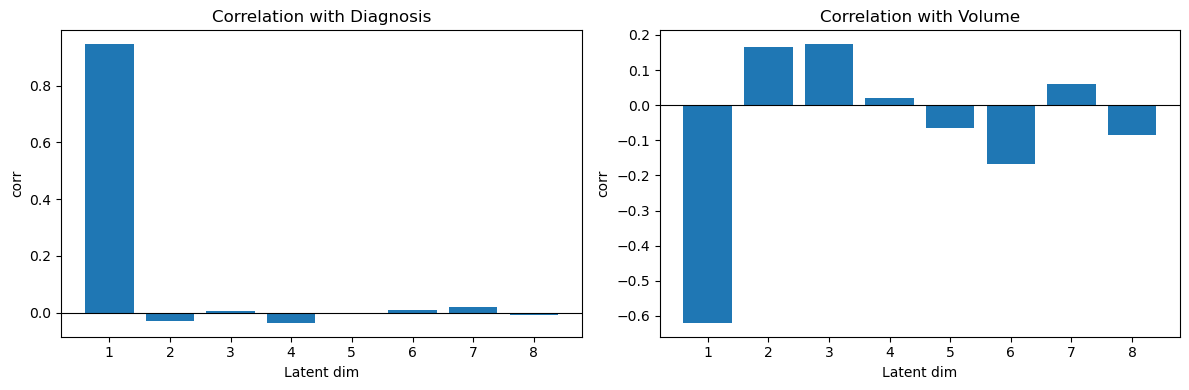

In [63]:
# Correlation per latent dimension with diagnosis and volume
corr_diag = []
corr_vol = []
for d in range(X.shape[1]):
    # diagnosis correlation (mask valid)
    mask_d = diagnosis >= 0
    if np.any(mask_d):
        corr = np.corrcoef(X[mask_d, d], diagnosis[mask_d])[0, 1]
    else:
        corr = float('nan')
    corr_diag.append(corr)
    # volume correlation (mask finite)
    mask_v = np.isfinite(volume)
    if np.any(mask_v):
        corr = np.corrcoef(X[mask_v, d], volume[mask_v])[0, 1]
    else:
        corr = float('nan')
    corr_vol.append(corr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 9), corr_diag)
axes[0].set_title('Correlation with Diagnosis')
axes[0].set_xlabel('Latent dim')
axes[0].set_ylabel('corr')
axes[0].axhline(0, color='k', linewidth=0.8)

axes[1].bar(range(1, 9), corr_vol)
axes[1].set_title('Correlation with Volume')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('corr')
axes[1].axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.show()


HLLE+ICA failed: for method='hessian', n_neighbors must be greater than [n_components * (n_components + 3) / 2]


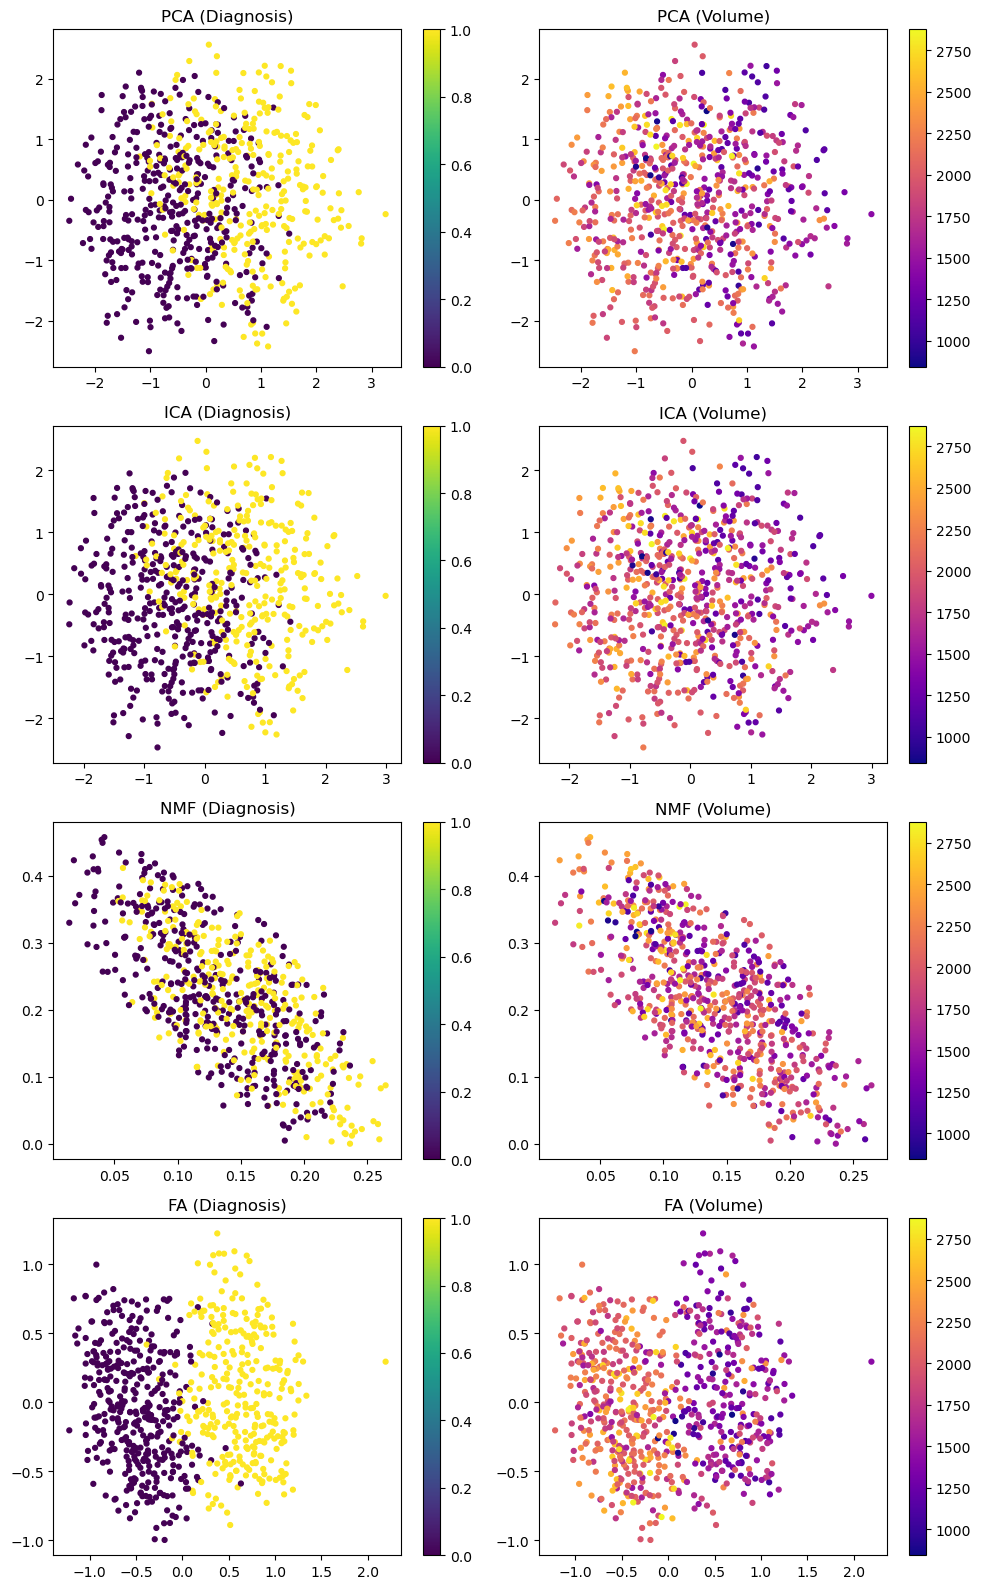

In [64]:
# Embeddings: PCA, ICA, NMF, FA, HLLE+ICA
X_std = StandardScaler().fit_transform(X)

results = {}

# PCA
pca = PCA(n_components=2)
results['PCA'] = pca.fit_transform(X_std)

# ICA
ica = FastICA(n_components=2, random_state=0)
results['ICA'] = ica.fit_transform(X_std)

# NMF (requires non-negative)
X_nn = MinMaxScaler().fit_transform(X)
nmf = NMF(n_components=2, init='nndsvda', random_state=0, max_iter=500)
results['NMF'] = nmf.fit_transform(X_nn)

# Factor Analysis
fa = FactorAnalysis(n_components=2, random_state=0)
results['FA'] = fa.fit_transform(X_std)

# HLLE + ICA (HLLE to 6D, then ICA to 2D)
try:
    hlle = LocallyLinearEmbedding(n_neighbors=10, n_components=6, method='hessian', eigen_solver='dense')
    Y_hlle = hlle.fit_transform(X_std)
    ica2 = FastICA(n_components=2, random_state=0)
    results['HLLE+ICA'] = ica2.fit_transform(Y_hlle)
except Exception as e:
    print('HLLE+ICA failed:', e)

# Plot embeddings colored by diagnosis and volume
fig, axes = plt.subplots(len(results), 2, figsize=(10, 4 * len(results)))
if len(results) == 1:
    axes = np.array([axes])
for i, (name, Y) in enumerate(results.items()):
    mask_d = diagnosis >= 0
    ax = axes[i, 0]
    sc = ax.scatter(Y[mask_d, 0], Y[mask_d, 1], c=diagnosis[mask_d], cmap='viridis', s=12)
    ax.set_title(f'{name} (Diagnosis)')
    plt.colorbar(sc, ax=ax)
    mask_v = np.isfinite(volume)
    ax = axes[i, 1]
    sc = ax.scatter(Y[mask_v, 0], Y[mask_v, 1], c=volume[mask_v], cmap='plasma', s=12)
    ax.set_title(f'{name} (Volume)')
    plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()


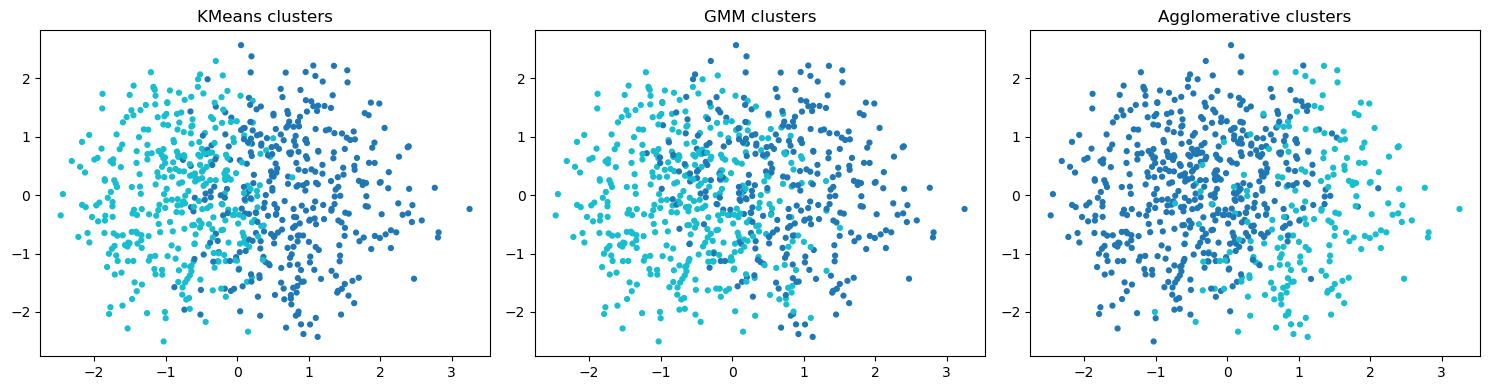

In [65]:
# Clustering on 8D latents
Xc = StandardScaler().fit_transform(X)

cluster_results = {}
cluster_results['KMeans'] = KMeans(n_clusters=2, random_state=0).fit_predict(Xc)
cluster_results['GMM'] = GaussianMixture(n_components=2, random_state=0).fit_predict(Xc)
cluster_results['Agglomerative'] = AgglomerativeClustering(n_clusters=2).fit_predict(Xc)

# Plot cluster assignments on PCA embedding
Y_pca = PCA(n_components=2).fit_transform(Xc)
fig, axes = plt.subplots(1, len(cluster_results), figsize=(5 * len(cluster_results), 4))
if len(cluster_results) == 1:
    axes = [axes]
for ax, (name, labels) in zip(axes, cluster_results.items()):
    sc = ax.scatter(Y_pca[:, 0], Y_pca[:, 1], c=labels, cmap='tab10', s=12)
    ax.set_title(f'{name} clusters')
plt.tight_layout()
plt.show()


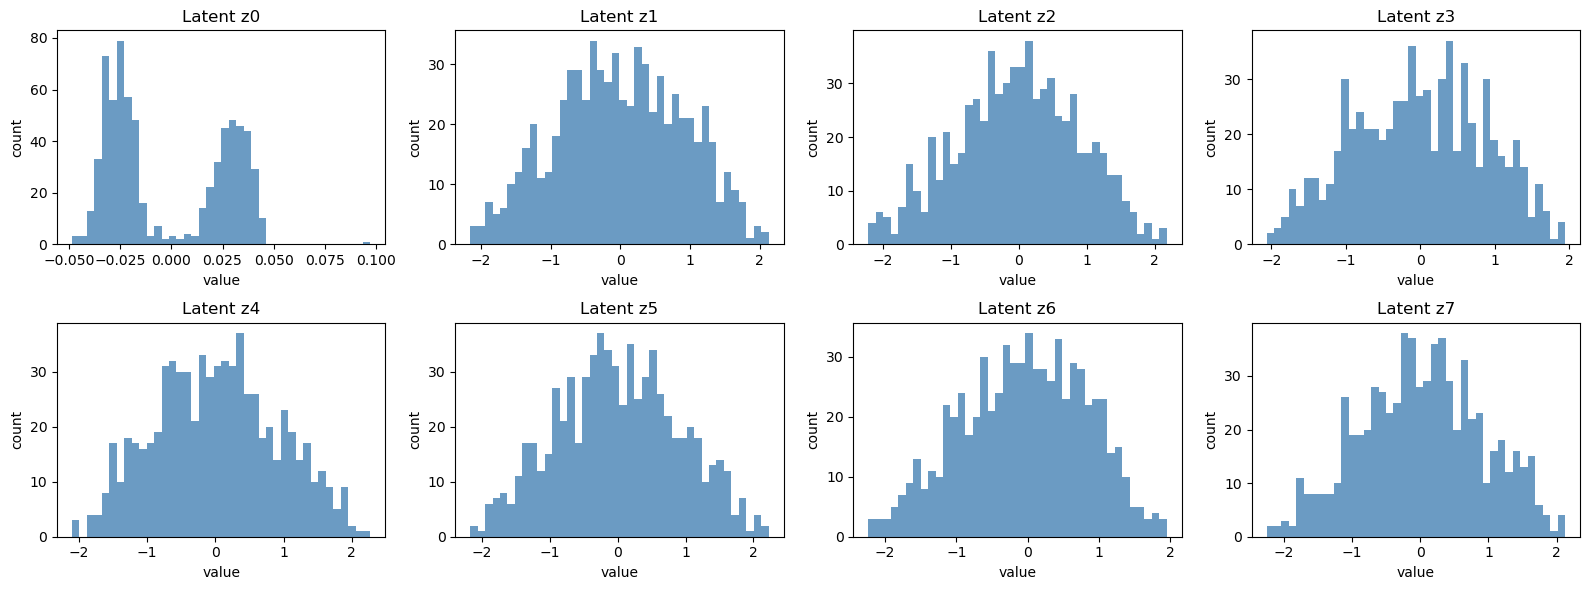

In [66]:
# Latent distributions for each of 8 variables
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i in range(8):
    ax = axes[i]
    ax.hist(X[:, i], bins=40, color='steelblue', alpha=0.8)
    ax.set_title(f'Latent z{i}')
    ax.set_xlabel('value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()


## 8D Latent Analysis (Pseudo-Label Model, Real Labels for Analysis)
This repeats the 8D analysis for the **pseudo-label model**, but uses **real labels (labels.pt)** for diagnosis/volume.


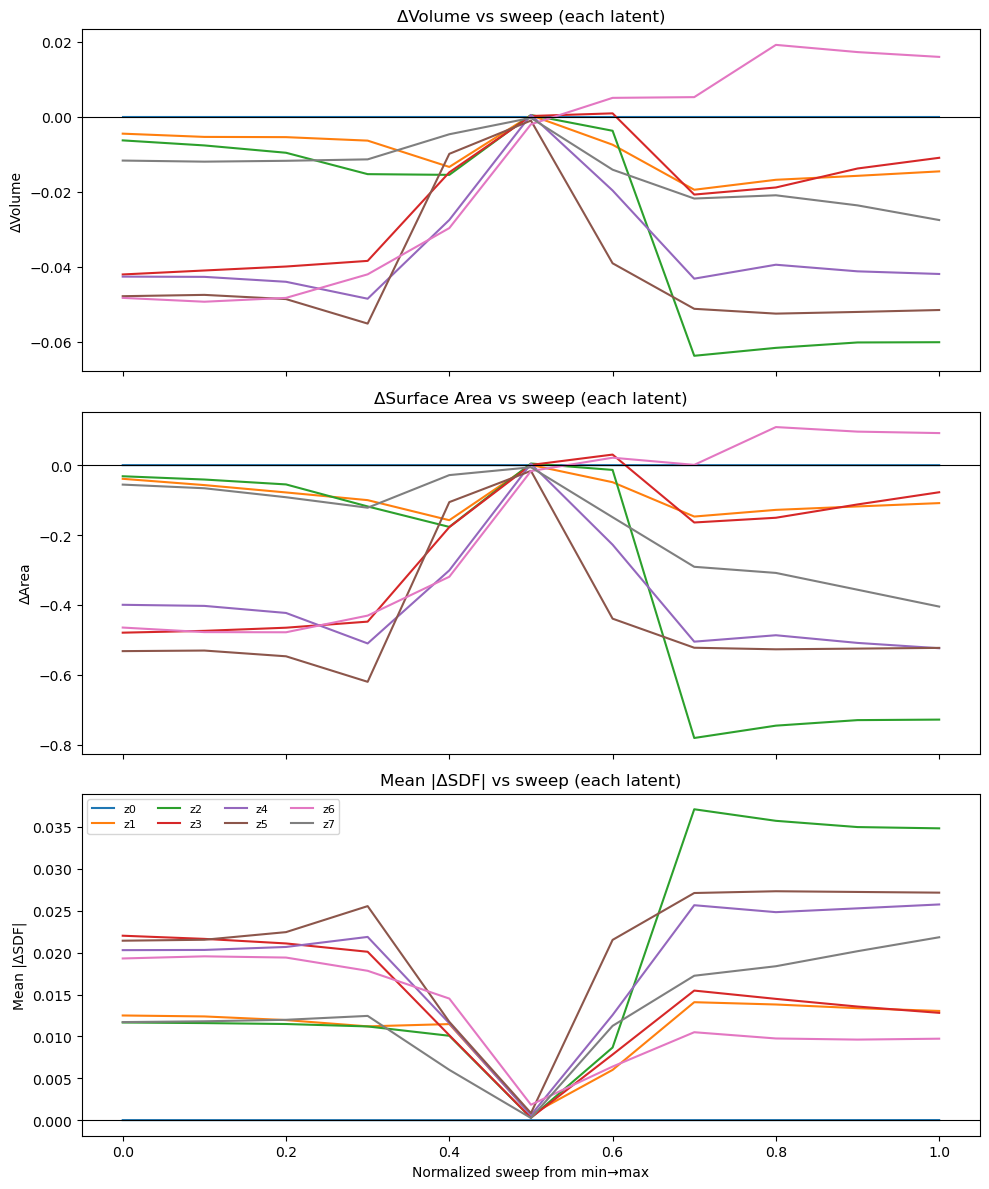

In [79]:
# Sweep each latent one-by-one: Δvolume, Δsurface area, mean|ΔSDF|
import numpy as np
import matplotlib.pyplot as plt

# Use real-label model
REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
vae_real.eval()
sdf_dec_real.eval()

# Load 8D latents and compute mean + range
latents_8d = load_latents(REAL_EXP)
minv, maxv, meanv = latent_stats(latents_8d)
mean_z = meanv.cpu().numpy()

grid_n = 64
max_batch = 32768 if device.type == 'cuda' else 8192

# Baseline at mean
base_mesh, base_sdf, base_origin, base_voxel = latent_to_mesh(
    mean_z, vae_real, sdf_dec_real, device, grid_n=grid_n, max_batch=max_batch, return_sdf=True
)
base_vol = volume_from_sdf(base_sdf, base_voxel)
base_area = float(base_mesh.area) if base_mesh is not None else None

sweep_pts = 11
zs = np.linspace(0.0, 1.0, sweep_pts)

delta_vol = []
delta_area = []
delta_sdf = []

for d in range(8):
    dv = []
    da = []
    ds = []
    zmin = float(minv[d].item())
    zmax = float(maxv[d].item())
    for t in zs:
        z = mean_z.copy()
        z[d] = zmin + t * (zmax - zmin)
        mesh, sdf, origin, voxel = latent_to_mesh(
            z, vae_real, sdf_dec_real, device, grid_n=grid_n, max_batch=max_batch, return_sdf=True
        )
        vol = volume_from_sdf(sdf, voxel)
        area = float(mesh.area) if mesh is not None else None
        if base_sdf is not None and sdf is not None and base_sdf.shape == sdf.shape:
            ds.append(float(np.mean(np.abs(sdf - base_sdf))))
        else:
            ds.append(float('nan'))
        dv.append(vol - base_vol if (vol is not None and base_vol is not None) else float('nan'))
        da.append(area - base_area if (area is not None and base_area is not None) else float('nan'))
    delta_vol.append(dv)
    delta_area.append(da)
    delta_sdf.append(ds)

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
for d in range(8):
    axes[0].plot(zs, delta_vol[d], label=f'z{d}')
axes[0].set_title('ΔVolume vs sweep (each latent)')
axes[0].set_ylabel('ΔVolume')
axes[0].axhline(0, color='k', linewidth=0.8)

for d in range(8):
    axes[1].plot(zs, delta_area[d], label=f'z{d}')
axes[1].set_title('ΔSurface Area vs sweep (each latent)')
axes[1].set_ylabel('ΔArea')
axes[1].axhline(0, color='k', linewidth=0.8)

for d in range(8):
    axes[2].plot(zs, delta_sdf[d], label=f'z{d}')
axes[2].set_title('Mean |ΔSDF| vs sweep (each latent)')
axes[2].set_ylabel('Mean |ΔSDF|')
axes[2].set_xlabel('Normalized sweep from min→max')
axes[2].axhline(0, color='k', linewidth=0.8)

axes[2].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [80]:
# Latent stats + suggested sweep ranges (mean ± 3*std)
latents_8d = load_latents(EXPERIMENTS["real_label"])
meanv = latents_8d.mean(dim=0)
stdv = latents_8d.std(dim=0)
minv = latents_8d.min(dim=0).values
maxv = latents_8d.max(dim=0).values

print('dim | min | max | mean | std | mean±3std')
for d in range(latents_8d.shape[1]):
    m = float(meanv[d])
    s = float(stdv[d])
    mn = float(minv[d])
    mx = float(maxv[d])
    lo = m - 3*s
    hi = m + 3*s
    print(f'z{d}: {mn:+.4f} {mx:+.4f} {m:+.4f} {s:.4f}  [{lo:+.4f}, {hi:+.4f}]')

# Flag near-collapsed dims
tiny = (stdv < 1e-3).cpu().numpy()
print('Near-constant dims (std<1e-3):', np.where(tiny)[0].tolist())


dim | min | max | mean | std | mean±3std
z0: -0.0191 +0.0271 -0.0007 0.0105  [-0.0321, +0.0307]
z1: -2.2459 +2.1265 -0.0194 0.8985  [-2.7149, +2.6761]
z2: -2.1566 +2.1475 +0.0083 0.9054  [-2.7079, +2.7244]
z3: -2.0177 +1.9569 -0.0413 0.9095  [-2.7698, +2.6872]
z4: -2.2596 +2.1945 +0.0062 0.8862  [-2.6523, +2.6647]
z5: -2.2011 +2.2711 -0.0046 0.8921  [-2.6810, +2.6718]
z6: -2.1976 +2.0186 -0.0050 0.8889  [-2.6719, +2.6618]
z7: -2.0882 +2.1381 +0.0142 0.8907  [-2.6579, +2.6864]
Near-constant dims (std<1e-3): []


In [88]:
# Test decoder sensitivity: Δcode for z0 vs z1 on a real sample
import numpy as np

REAL_EXP = EXPERIMENTS["real_label"]
specs_real, vae_real, sdf_dec_real, epoch_real = load_models(REAL_EXP, device)
vae_real.eval()

latents_8d = load_latents(REAL_EXP)

# pick a real sample (not mean)
idx = np.random.randint(0, latents_8d.shape[0])
z = latents_8d[idx].to(device).float()
print('Using sample idx:', idx)

def delta_code(z, dim, delta):
    z_plus = z.clone()
    z_minus = z.clone()
    z_plus[dim] += delta
    z_minus[dim] -= delta
    with torch.no_grad():
        c_plus = vae_real.decoder(z_plus.unsqueeze(0))
        c_minus = vae_real.decoder(z_minus.unsqueeze(0))
    return float(torch.norm(c_plus - c_minus, p=2).item())

deltas = [0.01, 0.05, 0.1, 0.2, 0.5]

print('Δcode(z0):')
for d in deltas:
    print(f'  Δ={d:.3f} -> {delta_code(z, 0, d):.6f}')

print('Δcode(z1):')
for d in deltas:
    print(f'  Δ={d:.3f} -> {delta_code(z, 1, d):.6f}')

# ratio at Δ=0.1 (if both computed)
try:
    dc0 = delta_code(z, 0, 0.1)
    dc1 = delta_code(z, 1, 0.1)
    print(f'Ratio Δcode(z0)/Δcode(z1) at Δ=0.1: {dc0/dc1:.4f}')
except Exception as e:
    print('Ratio compute failed:', e)


Using sample idx: 256
Δcode(z0):
  Δ=0.010 -> 0.000132
  Δ=0.050 -> 0.000659
  Δ=0.100 -> 0.001318
  Δ=0.200 -> 0.002636
  Δ=0.500 -> 0.006587
Δcode(z1):
  Δ=0.010 -> 0.006619
  Δ=0.050 -> 0.033066
  Δ=0.100 -> 0.065945
  Δ=0.200 -> 0.130566
  Δ=0.500 -> 0.316595
Ratio Δcode(z0)/Δcode(z1) at Δ=0.1: 0.0200
